<a href="https://colab.research.google.com/github/bijelic02/myRAGProject/blob/main/MyRAGProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase **1**
Environment & Data Setup



Connect to Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("Mounted successfully")

Mounted at /content/drive
Mounted successfully


This mounts your Google Drive into Colab. When you run it, it asks for permission once and then your Drive is accessible at `/content/drive/MyDrive/`. Your notebook file itself (`.ipynb`) gets saved to Drive automatically if you set it up right.

**Save the notebook itself to Drive**

In Colab go to:
```
File → Save a copy in Drive
```

This moves your notebook from Colab's temporary storage into your actual Google Drive. From that point on, `Ctrl+S` saves it there. Never work from the default "Colab Notebooks" auto-created file without doing this first.
---

**Also save to GitHub (highly recommended)**

The spec specifically asks for a GitHub repo as a deliverable anyway, so set it up early:
```
File → Save a copy in GitHub


Install dependencies

In [17]:
!pip install transformers torch accelerate bitsandbytes \
             sentence-transformers \
             faiss-cpu chromadb \
             rank-bm25 \
             langchain langchain-community nltk \
             gradio \
             pypdf beautifulsoup4 requests \
             wikipedia-api \
             langchain-text-splitters \
             pandas numpy tqdm scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.

Check if everything is actually installed correctly

In [18]:
import transformers
import torch
import sentence_transformers
import faiss
import chromadb
import gradio
import langchain
from rank_bm25 import BM25Okapi
import pandas as pd
import sklearn
import wikipediaapi
import json
import os
from datetime import datetime

print("transformers:", transformers.__version__)
print("torch:", torch.__version__)
print("sentence_transformers:", sentence_transformers.__version__)
print("faiss version: OK")
print("chromadb:", chromadb.__version__)
print("gradio:", gradio.__version__)
print("langchain:", langchain.__version__)
print("pandas:", pd.__version__)
print("GPU available:", torch.cuda.is_available())

ImportError: cannot import name '_ON_EMIT_RECURSION_COUNT_KEY' from 'opentelemetry.context' (/usr/local/lib/python3.12/dist-packages/opentelemetry/context/__init__.py)

Define documents list with metadata

In [ ]:
DOCUMENTS = [
    {
        "title": "Rodent",
        "url": "https://en.wikipedia.org/wiki/Rodent",
        "category": "overview",
        "topic": "rodents"
    },
    {
        "title": "List of rodents",
        "url": "https://en.wikipedia.org/wiki/List_of_rodents",
        "category": "overview",
        "topic": "rodents"
    },
    {
        "title": "Beaver",
        "url": "https://en.wikipedia.org/wiki/Beaver",
        "category": "species",
        "topic": "rodents"
    },
    {
        "title": "Nutria",
        "url": "https://en.wikipedia.org/wiki/Nutria",
        "category": "species",
        "topic": "rodents"
    },
    {
        "title": "Gopher",
        "url": "https://en.wikipedia.org/wiki/Gopher",
        "category": "species",
        "topic": "rodents"
    },
    {
        "title": "Chinchilla",
        "url": "https://en.wikipedia.org/wiki/Chinchilla",
        "category": "species",
        "topic": "rodents"
    },
    {
        "title": "Squirrel",
        "url": "https://en.wikipedia.org/wiki/Squirrel",
        "category": "species",
        "topic": "rodents"
    },
    {
        "title": "Capybara",
        "url": "https://en.wikipedia.org/wiki/Capybara",
        "category": "species",
        "topic": "rodents"
    },
    {
        "title": "Guinea pig",
        "url": "https://en.wikipedia.org/wiki/Guinea_pig",
        "category": "species",
        "topic": "rodents"
    },
    {
        "title": "Marmot",
        "url": "https://en.wikipedia.org/wiki/Marmot",
        "category": "species",
        "topic": "rodents"
    },
    {
        "title": "Pika",
        "url": "https://en.wikipedia.org/wiki/Pika",
        "category": "species",
        "topic": "rodents"
    },
    {
        "title": "Rabbit",
        "url": "https://en.wikipedia.org/wiki/Rabbit",
        "category": "species",
        "topic": "rodents"
    },
    {
        "title": "Rat",
        "url": "https://en.wikipedia.org/wiki/Rat",
        "category": "species",
        "topic": "rodents"
    },
]

print(f"Defined {len(DOCUMENTS)} documents")

Defined 13 documents


Fetch and normalize documents

In [ ]:
def fetch_wikipedia_page(wiki, title):
    """Fetch a single Wikipedia page and return its text."""
    page = wiki.page(title)
    if not page.exists():
        print(f"  WARNING: Page '{title}' not found")
        return None
    return page.text

In [ ]:
def normalize_text(text):
    """Basic text normalization."""
    # Remove excessive newlines
    lines = text.split('\n')
    # Filter out very short lines (usually section headers or empty)
    lines = [line.strip() for line in lines if len(line.strip()) > 30]
    return ' '.join(lines)

In [ ]:
def ingest_documents(document_list, save_path):
    """Fetch all documents from Wikipedia and save with metadata."""

    # Initialize Wikipedia API
    wiki = wikipediaapi.Wikipedia(
        language='en',
        user_agent='RodentRAGProject/1.0'
    )

    ingested = []
    failed = []

    for doc in document_list:
        print(f"Fetching: {doc['title']}...")

        try:
            raw_text = fetch_wikipedia_page(wiki, doc['title'])

            if raw_text is None:
                failed.append(doc['title'])
                continue

            clean_text = normalize_text(raw_text)

            # Build the full document object with metadata
            document = {
                "id": doc['title'].lower().replace(' ', '_'),
                "title": doc['title'],
                "text": clean_text,
                "metadata": {
                    "source": doc['url'],
                    "category": doc['category'],
                    "topic": doc['topic'],
                    "date_ingested": datetime.now().strftime("%Y-%m-%d"),
                    "char_count": len(clean_text),
                    "word_count": len(clean_text.split())
                }
            }

            ingested.append(document)
            print(f"  OK — {document['metadata']['word_count']} words")

        except Exception as e:
            print(f"  FAILED: {e}")
            failed.append(doc['title'])

    # Save to JSON file on Drive
    os.makedirs(save_path, exist_ok=True)
    output_file = os.path.join(save_path, 'documents.json')

    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(ingested, f, indent=2, ensure_ascii=False)

    print(f"\n{'='*40}")
    print(f"Successfully ingested: {len(ingested)} documents")
    print(f"Failed: {len(failed)} documents {failed if failed else ''}")
    print(f"Saved to: {output_file}")

    return ingested



In [ ]:
# Run ingestion - saves to Google Drive
DOCS_SAVE_PATH = "/content/drive/MyDrive/rag_project/documents"


In [ ]:
documents = ingest_documents(DOCUMENTS, DOCS_SAVE_PATH)

Fetching: Rodent...
  OK — 6977 words
Fetching: List of rodents...
  OK — 2111 words
Fetching: Beaver...
  OK — 5947 words
Fetching: Nutria...
  OK — 4645 words
Fetching: Gopher...
  OK — 1169 words
Fetching: Chinchilla...
  OK — 1605 words
Fetching: Squirrel...
  OK — 1979 words
Fetching: Capybara...
  OK — 2160 words
Fetching: Guinea pig...
  OK — 7287 words
Fetching: Marmot...
  OK — 692 words
Fetching: Pika...
  OK — 2107 words
Fetching: Rabbit...
  OK — 6555 words
Fetching: Rat...
  OK — 4628 words

Successfully ingested: 13 documents
Failed: 0 documents 
Saved to: /content/drive/MyDrive/rag_project/documents/documents.json


Preview what you fetched

In [ ]:
def preview_documents(docs):
    """Print a summary table of all ingested documents."""

    rows = []
    for doc in docs:
        rows.append({
            "ID": doc['id'],
            "Title": doc['title'],
            "Category": doc['metadata']['category'],
            "Words": doc['metadata']['word_count'],
            "Chars": doc['metadata']['char_count'],
            "Date Ingested": doc['metadata']['date_ingested']
        })

    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    print(f"\nTotal words across all documents: {df['Words'].sum():,}")
    print(f"Average words per document: {df['Words'].mean():.0f}")

In [ ]:


preview_documents(documents)

             ID           Title Category  Words  Chars Date Ingested
         rodent          Rodent overview   6977  44898    2026-03-31
list_of_rodents List of rodents overview   2111  14286    2026-03-31
         beaver          Beaver  species   5947  36695    2026-03-31
         nutria          Nutria  species   4645  29168    2026-03-31
         gopher          Gopher  species   1169   7577    2026-03-31
     chinchilla      Chinchilla  species   1605  10184    2026-03-31
       squirrel        Squirrel  species   1979  12876    2026-03-31
       capybara        Capybara  species   2160  13378    2026-03-31
     guinea_pig      Guinea pig  species   7287  45021    2026-03-31
         marmot          Marmot  species    692   4338    2026-03-31
           pika            Pika  species   2107  14352    2026-03-31
         rabbit          Rabbit  species   6555  40597    2026-03-31
            rat             Rat  species   4628  29119    2026-03-31

Total words across all documents:

Load documents back from Drive (for future sessions)

In [ ]:
def load_documents(save_path):
    """Load previously ingested documents from Drive."""
    output_file = os.path.join(save_path, 'documents.json')

    if not os.path.exists(output_file):
        print("No saved documents found. Run ingestion first.")
        return []

    with open(output_file, 'r', encoding='utf-8') as f:
        docs = json.load(f)

    print(f"Loaded {len(docs)} documents from {output_file}")
    return docs

# In future sessions, instead of re-fetching from Wikipedia,
# just call this:
# documents = load_documents(DOCS_SAVE_PATH)

# Phase **2**
Three types of chunking



First - we want to load our files from drive

In [4]:
# This is a copy of code from phase 1
DOCS_SAVE_PATH = "/content/drive/MyDrive/rag_project/documents"


In [5]:
def load_documents(save_path):
    """Load previously ingested documents from Drive."""
    output_file = os.path.join(save_path, 'documents.json')

    if not os.path.exists(output_file):
        print("No saved documents found. Run ingestion first.")
        return []

    with open(output_file, 'r', encoding='utf-8') as f:
        docs = json.load(f)

    print(f"Loaded {len(docs)} documents from {output_file}")
    return docs


In [11]:
documents = load_documents(DOCS_SAVE_PATH)

Loaded 13 documents from /content/drive/MyDrive/rag_project/documents/documents.json


In [13]:
!pip install langchain-text-splitters -q

In [15]:
from langchain_text_splitters import CharacterTextSplitter

Function for splitting text in **fixed size chunking**

> later we will discuss how size of chunk and overlap affects model




In [16]:
def fixed_size_chunking(documents, chunk_size=500, chunk_overlap=50):
    """
    Split documents into fixed size chunks.

    Parameters:
    - documents: list of document dicts from documents.json
    - chunk_size: how many characters per chunk
    - chunk_overlap: how many characters to repeat between chunks
    """

    splitter = CharacterTextSplitter(
        separator=" ",        # split at spaces so we dont cut mid-word
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,  # measure size in characters
    )

    all_chunks = []

    for doc in documents:
        # Split the document text into chunks
        chunks = splitter.split_text(doc['text'])

        # For each chunk, keep track of where it came from
        for i, chunk_text in enumerate(chunks):
            chunk = {
                "text": chunk_text,
                "metadata": {
                    "chunk_id": f"{doc['id']}_fixed_{i}",
                    "doc_id": doc['id'],
                    "title": doc['title'],
                    "source": doc['metadata']['source'],
                    "category": doc['metadata']['category'],
                    "chunk_index": i,
                    "total_chunks": len(chunks),
                    "chunk_size": chunk_size,
                    "chunk_overlap": chunk_overlap,
                    "chunking_strategy": "fixed_size"
                }
            }
            all_chunks.append(chunk)

    return all_chunks

Run it and see results

In [17]:
# Run fixed size chunking on all documents
fixed_chunks = fixed_size_chunking(documents, chunk_size=500, chunk_overlap=50)

# Basic stats
print(f"Total chunks created: {len(fixed_chunks)}")
print(f"Average chunk length: {sum(len(c['text']) for c in fixed_chunks) / len(fixed_chunks):.0f} chars")
print(f"Shortest chunk: {min(len(c['text']) for c in fixed_chunks)} chars")
print(f"Longest chunk: {max(len(c['text']) for c in fixed_chunks)} chars")

Total chunks created: 677
Average chunk length: 493 chars
Shortest chunk: 83 chars
Longest chunk: 500 chars


Inspect a real chunk to see what it looks like

In [18]:
# Look at first 3 chunks from the Capybara document
capybara_chunks = [c for c in fixed_chunks if c['metadata']['doc_id'] == 'capybara']

print(f"Capybara was split into {len(capybara_chunks)} chunks\n")
print("=" * 60)

for i, chunk in enumerate(capybara_chunks[:3]):
    print(f"\nCHUNK {i+1}:")
    print(f"Characters: {len(chunk['text'])}")
    print(f"Chunk ID: {chunk['metadata']['chunk_id']}")
    print(f"Text preview:")
    print(f"{chunk['text'][:200]}...")
    print("=" * 60)

Capybara was split into 30 chunks


CHUNK 1:
Characters: 491
Chunk ID: capybara_fixed_0
Text preview:
The capybara or greater capybara (Hydrochoerus hydrochaeris) is the largest living rodent, native to all countries in South America except Chile. It is a semiaquatic herbivore that inhabits savannas a...

CHUNK 2:
Characters: 499
Chunk ID: capybara_fixed_1
Text preview:
it is more distantly related to the agouti, the chinchilla, and the nutria. The capybara is a highly social species that usually lives in groups of 10–20 individuals, but can be found in groups as lar...

CHUNK 3:
Characters: 495
Chunk ID: capybara_fixed_2
Text preview:
"one who eats slender leaves", or "grass-eater". The genus name, hydrochoerus, comes from Greek ὕδωρ (hýdor "water") and χοῖρος (choíros "pig, hog") and the species name, hydrochaeris, comes from Gree...


Compare different chunk sizes

In [19]:
# See how chunk size affects number of chunks produced
print("Chunk size comparison:")
print(f"{'Chunk Size':>12} | {'Total Chunks':>12} | {'Avg Length':>10}")
print("-" * 42)

for size in [256, 512, 1000]:
    chunks = fixed_size_chunking(documents, chunk_size=size, chunk_overlap=50)
    avg_len = sum(len(c['text']) for c in chunks) / len(chunks)
    print(f"{size:>12} | {len(chunks):>12} | {avg_len:>10.0f}")


Chunk size comparison:
  Chunk Size | Total Chunks | Avg Length
------------------------------------------
         256 |         1472 |        252
         512 |          658 |        505
        1000 |          324 |        978


Save fixed chunks to Drive

In [21]:
import json
import os

CHUNKS_PATH = "/content/drive/MyDrive/rag_project/chunks"
os.makedirs(CHUNKS_PATH, exist_ok=True)

for size in [256, 512, 1000]:
    chunks = fixed_size_chunking(documents, chunk_size=size, chunk_overlap=50)

    filename = f"{CHUNKS_PATH}/fixed_chunks_{size}.json"
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(chunks, f, indent=2, ensure_ascii=False)

    print(f"Saved {len(chunks)} chunks of size {size} → fixed_chunks_{size}.json")

Saved 1472 chunks of size 256 → fixed_chunks_256.json
Saved 658 chunks of size 512 → fixed_chunks_512.json
Saved 324 chunks of size 1000 → fixed_chunks_1000.json


Function for splitting text wirh **recursive chunking**

later we will discuss how size of chunk and overlap affects model

Import

In [22]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [23]:
def recursive_chunking(documents, chunk_size=500, chunk_overlap=50):
    """
    Split documents using recursive character splitting.
    Tries to split at natural boundaries in this order:
    paragraphs -> lines -> sentences -> words -> characters

    Parameters:
    - documents: list of document dicts from documents.json
    - chunk_size: target size of each chunk in characters
    - chunk_overlap: characters to repeat between chunks
    """

    splitter = RecursiveCharacterTextSplitter(
        separators=["\n\n", "\n", ". ", " ", ""],
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
    )

    all_chunks = []

    for doc in documents:
        chunks = splitter.split_text(doc['text'])

        for i, chunk_text in enumerate(chunks):
            chunk = {
                "text": chunk_text,
                "metadata": {
                    "chunk_id": f"{doc['id']}_recursive_{i}",
                    "doc_id": doc['id'],
                    "title": doc['title'],
                    "source": doc['metadata']['source'],
                    "category": doc['metadata']['category'],
                    "chunk_index": i,
                    "total_chunks": len(chunks),
                    "chunk_size": chunk_size,
                    "chunk_overlap": chunk_overlap,
                    "chunking_strategy": "recursive"
                }
            }
            all_chunks.append(chunk)

    return all_chunks

separators=["\n\n", "\n", ". ", " ", ""] - explanation


It tries each separator in order

```
"\n\n" → first try to split at paragraph breaks
"\n"   → if still too big, split at line breaks  
". "   → if still too big, split at sentences
" "    → if still too big, split at words
""     → last resort, split at any character
```

Run and compare with fixed size

In [24]:
recursive_chunks = recursive_chunking(documents, chunk_size=500, chunk_overlap=50)

print("=== RECURSIVE CHUNKING RESULTS ===")
print(f"Total chunks: {len(recursive_chunks)}")
print(f"Average length: {sum(len(c['text']) for c in recursive_chunks) / len(recursive_chunks):.0f} chars")
print(f"Shortest chunk: {min(len(c['text']) for c in recursive_chunks)} chars")
print(f"Longest chunk: {max(len(c['text']) for c in recursive_chunks)} chars")

print("\n=== COMPARISON WITH FIXED SIZE ===")
print(f"{'Method':>15} | {'Total Chunks':>12} | {'Avg Length':>10}")
print("-" * 45)
print(f"{'Fixed Size':>15} | {len(fixed_chunks):>12} | {sum(len(c['text']) for c in fixed_chunks)/len(fixed_chunks):>10.0f}")
print(f"{'Recursive':>15} | {len(recursive_chunks):>12} | {sum(len(c['text']) for c in recursive_chunks)/len(recursive_chunks):>10.0f}")

=== RECURSIVE CHUNKING RESULTS ===
Total chunks: 729
Average length: 418 chars
Shortest chunk: 66 chars
Longest chunk: 500 chars

=== COMPARISON WITH FIXED SIZE ===
         Method | Total Chunks | Avg Length
---------------------------------------------
     Fixed Size |          677 |        493
      Recursive |          729 |        418


Compare a real chunk side by side

In [28]:
# Look at same section of Capybara document in both methods
fixed_capybara = [c for c in fixed_chunks if c['metadata']['doc_id'] == 'capybara']
recursive_capybara = [c for c in recursive_chunks if c['metadata']['doc_id'] == 'capybara']

print("FIXED SIZE - Chunk 1:")
print(fixed_capybara[0]['text'])
print("\n" + "="*60)
print("\nRECURSIVE - Chunk 1:")
print(recursive_capybara[0]['text'])

FIXED SIZE - Chunk 1:
The capybara or greater capybara (Hydrochoerus hydrochaeris) is the largest living rodent, native to all countries in South America except Chile. It is a semiaquatic herbivore that inhabits savannas and dense forests, living near and in bodies of water and feeding mainly on grasses and aquatic plants. Together with the lesser capybara, it constitutes the genus Hydrochoerus. Its other close relatives include guinea pigs and rock cavies, and it is more distantly related to the agouti, the


RECURSIVE - Chunk 1:
The capybara or greater capybara (Hydrochoerus hydrochaeris) is the largest living rodent, native to all countries in South America except Chile. It is a semiaquatic herbivore that inhabits savannas and dense forests, living near and in bodies of water and feeding mainly on grasses and aquatic plants. Together with the lesser capybara, it constitutes the genus Hydrochoerus


Save three size of recursive chunking on drive

In [29]:
for size in [256, 512, 1000]:
    chunks = recursive_chunking(documents, chunk_size=size, chunk_overlap=50)

    filename = f"{CHUNKS_PATH}/recursive_chunks_{size}.json"
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(chunks, f, indent=2, ensure_ascii=False)

    print(f"Saved {len(chunks)} chunks of size {size} → recursive_chunks_{size}.json")


Saved 1657 chunks of size 256 → recursive_chunks_256.json
Saved 705 chunks of size 512 → recursive_chunks_512.json
Saved 333 chunks of size 1000 → recursive_chunks_1000.json


Function for splitting text wirh **semantical chunking**

later we will discuss how size of chunk and overlap affects model

 Install and import

In [30]:
!pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer
import numpy as np
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Load embedding model

 We WILL NOT use this model to embed chunks, we'll use it to embed sentances. After thah we'll know similarity between each sentance and we'll know how to divide them into chunks.

In [31]:
print("Loading embedding model for semantic chunking...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded!")

Loading embedding model for semantic chunking...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


Semantic chunking function

In [32]:
def semantic_chunking(documents, embedding_model, threshold=0.3, min_chunk_size=100, max_chunk_size=1000):
    """
    Split documents based on semantic similarity between sentences.
    When similarity drops significantly between consecutive sentences,
    that signals a topic change and we split there.

    Parameters:
    - documents: list of document dicts from documents.json
    - embedding_model: SentenceTransformer model for embeddings
    - threshold: similarity drop that triggers a split (lower = more splits)
    - min_chunk_size: minimum characters a chunk must have
    - max_chunk_size: maximum characters a chunk can have
    """

    def get_similarity(emb1, emb2):
        """Calculate cosine similarity between two embeddings."""
        return float(np.dot(emb1, emb2) /
                    (np.linalg.norm(emb1) * np.linalg.norm(emb2)))

    def split_into_chunks(sentences, embeddings, threshold, min_size, max_size):
        """Group sentences into chunks based on similarity drops."""

        if len(sentences) == 0:
            return []

        chunks = []
        current_chunk_sentences = [sentences[0]]
        current_chunk_size = len(sentences[0])

        for i in range(1, len(sentences)):
            current_sentence = sentences[i]
            sentence_size = len(current_sentence)

            # Calculate similarity between current and previous sentence
            similarity = get_similarity(embeddings[i-1], embeddings[i])

            # Decide whether to split or continue current chunk
            should_split = False

            # Split if similarity drops below threshold (topic change)
            if similarity < threshold:
                should_split = True

            # Force split if chunk is getting too large
            if current_chunk_size + sentence_size > max_size:
                should_split = True

            # Never split if chunk is too small
            if current_chunk_size < min_size:
                should_split = False

            if should_split:
                # Save current chunk and start new one
                chunks.append(' '.join(current_chunk_sentences))
                current_chunk_sentences = [current_sentence]
                current_chunk_size = sentence_size
            else:
                # Add sentence to current chunk
                current_chunk_sentences.append(current_sentence)
                current_chunk_size += sentence_size

        # Don't forget the last chunk
        if current_chunk_sentences:
            chunks.append(' '.join(current_chunk_sentences))

        return chunks

    all_chunks = []

    for doc_index, doc in enumerate(documents):
        print(f"Processing {doc['title']} ({doc_index + 1}/{len(documents)})...")

        # Step 1 - Split document into sentences
        sentences = sent_tokenize(doc['text'])

        # Remove very short sentences (noise)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 20]

        if len(sentences) == 0:
            print(f"  WARNING: No sentences found in {doc['title']}")
            continue

        # Step 2 - Embed all sentences at once (faster than one by one)
        embeddings = embedding_model.encode(sentences, show_progress_bar=False)

        # Step 3 - Group sentences into chunks based on similarity
        chunk_texts = split_into_chunks(
            sentences,
            embeddings,
            threshold=threshold,
            min_size=min_chunk_size,
            max_size=max_chunk_size
        )

        # Step 4 - Build chunk objects with metadata
        for i, chunk_text in enumerate(chunk_texts):
            chunk = {
                "text": chunk_text,
                "metadata": {
                    "chunk_id": f"{doc['id']}_semantic_{i}",
                    "doc_id": doc['id'],
                    "title": doc['title'],
                    "source": doc['metadata']['source'],
                    "category": doc['metadata']['category'],
                    "chunk_index": i,
                    "total_chunks": len(chunk_texts),
                    "threshold": threshold,
                    "chunking_strategy": "semantic"
                }
            }
            all_chunks.append(chunk)

        print(f"  Created {len(chunk_texts)} chunks")

    return all_chunks

Run semantic chunking

In [33]:
print("Starting semantic chunking (this will take a few minutes)...")
print("It is slower than fixed/recursive because it embeds every sentence\n")

semantic_chunks = semantic_chunking(
    documents,
    embedding_model,
    threshold=0.3,
    min_chunk_size=100,
    max_chunk_size=1000
)

print(f"\n=== SEMANTIC CHUNKING RESULTS ===")
print(f"Total chunks: {len(semantic_chunks)}")
print(f"Average length: {sum(len(c['text']) for c in semantic_chunks) / len(semantic_chunks):.0f} chars")
print(f"Shortest chunk: {min(len(c['text']) for c in semantic_chunks)} chars")
print(f"Longest chunk: {max(len(c['text']) for c in semantic_chunks)} chars")

Starting semantic chunking (this will take a few minutes)...
It is slower than fixed/recursive because it embeds every sentence

Processing Rodent (1/13)...
  Created 96 chunks
Processing List of rodents (2/13)...
  Created 41 chunks
Processing Beaver (3/13)...
  Created 91 chunks
Processing Nutria (4/13)...
  Created 58 chunks
Processing Gopher (5/13)...
  Created 17 chunks
Processing Chinchilla (6/13)...
  Created 27 chunks
Processing Squirrel (7/13)...
  Created 24 chunks
Processing Capybara (8/13)...
  Created 32 chunks
Processing Guinea pig (9/13)...
  Created 91 chunks
Processing Marmot (10/13)...
  Created 9 chunks
Processing Pika (11/13)...
  Created 28 chunks
Processing Rabbit (12/13)...
  Created 68 chunks
Processing Rat (13/13)...
  Created 50 chunks

=== SEMANTIC CHUNKING RESULTS ===
Total chunks: 632
Average length: 477 chars
Shortest chunk: 21 chars
Longest chunk: 1603 chars


 Compare all three methods

In [35]:
print("=== COMPARISON OF ALL THREE CHUNKING METHODS ===\n")
print(f"{'Method':>15} | {'Total Chunks':>12} | {'Avg Length':>10} | {'Min':>6} | {'Max':>6}")
print("-" * 60)

methods = [
    ("Fixed Size", fixed_chunks),
    ("Recursive", recursive_chunks),
    ("Semantic", semantic_chunks)
]

for name, chunks in methods:
    lengths = [len(c['text']) for c in chunks]
    print(f"{name:>15} | {len(chunks):>12} | {sum(lengths)/len(lengths):>10.0f} | {min(lengths):>6} | {max(lengths):>6}")


=== COMPARISON OF ALL THREE CHUNKING METHODS ===

         Method | Total Chunks | Avg Length |    Min |    Max
------------------------------------------------------------
     Fixed Size |          677 |        493 |     83 |    500
      Recursive |          729 |        418 |     66 |    500
       Semantic |          632 |        477 |     21 |   1603


Look at real chunk

In [36]:
semantic_capybara = [c for c in semantic_chunks if c['metadata']['doc_id'] == 'capybara']

print(f"Capybara was split into {len(semantic_capybara)} semantic chunks\n")

for i, chunk in enumerate(semantic_capybara[:3]):
    print(f"CHUNK {i+1} ({len(chunk['text'])} chars):")
    print(chunk['text'][:300])
    print("=" * 60)

Capybara was split into 32 semantic chunks

CHUNK 1 (519 chars):
The capybara or greater capybara (Hydrochoerus hydrochaeris) is the largest living rodent, native to all countries in South America except Chile. It is a semiaquatic herbivore that inhabits savannas and dense forests, living near and in bodies of water and feeding mainly on grasses and aquatic plant
CHUNK 2 (142 chars):
The capybara is a highly social species that usually lives in groups of 10–20 individuals, but can be found in groups as large as one hundred.
CHUNK 3 (280 chars):
It is hunted for its meat and hide and for grease from its thick fatty skin. Its common name is derived from Tupi ka'apiûara, a complex agglutination of kaá (leaf) + píi (slender) + ú (eat) + ara (a suffix for agent nouns), meaning "one who eats slender leaves", or "grass-eater".


Test different thresholds

In [37]:
# Threshold controls how sensitive splitting is to topic changes
# Lower threshold = splits more often = more smaller chunks
# Higher threshold = splits less often = fewer larger chunks

print("Threshold comparison:")
print(f"{'Threshold':>12} | {'Total Chunks':>12} | {'Avg Length':>10}")
print("-" * 42)

for threshold in [0.2, 0.3, 0.5]:
    chunks = semantic_chunking(
        documents,
        embedding_model,
        threshold=threshold,
        min_chunk_size=100,
        max_chunk_size=1000
    )
    avg_len = sum(len(c['text']) for c in chunks) / len(chunks)
    print(f"{threshold:>12} | {len(chunks):>12} | {avg_len:>10.0f}")

Threshold comparison:
   Threshold | Total Chunks | Avg Length
------------------------------------------
Processing Rodent (1/13)...
  Created 67 chunks
Processing List of rodents (2/13)...
  Created 17 chunks
Processing Beaver (3/13)...
  Created 62 chunks
Processing Nutria (4/13)...
  Created 45 chunks
Processing Gopher (5/13)...
  Created 14 chunks
Processing Chinchilla (6/13)...
  Created 21 chunks
Processing Squirrel (7/13)...
  Created 20 chunks
Processing Capybara (8/13)...
  Created 20 chunks
Processing Guinea pig (9/13)...
  Created 74 chunks
Processing Marmot (10/13)...
  Created 7 chunks
Processing Pika (11/13)...
  Created 20 chunks
Processing Rabbit (12/13)...
  Created 59 chunks
Processing Rat (13/13)...
  Created 43 chunks
         0.2 |          469 |        643
Processing Rodent (1/13)...
  Created 96 chunks
Processing List of rodents (2/13)...
  Created 41 chunks
Processing Beaver (3/13)...
  Created 91 chunks
Processing Nutria (4/13)...
  Created 58 chunks
Processin

Save to drive

In [39]:
for threshold in [0.2, 0.3, 0.5]:
    chunks = semantic_chunking(
        documents,
        embedding_model,
        threshold=threshold,
        min_chunk_size=100,
        max_chunk_size=1000
    )

    filename = f"{CHUNKS_PATH}/semantic_chunks_{threshold}.json"
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(chunks, f, indent=2, ensure_ascii=False)

    print(f"Saved {len(chunks)} chunks with threshold {threshold} → semantic_chunks_{threshold}.json")


Processing Rodent (1/13)...
  Created 67 chunks
Processing List of rodents (2/13)...
  Created 17 chunks
Processing Beaver (3/13)...
  Created 62 chunks
Processing Nutria (4/13)...
  Created 45 chunks
Processing Gopher (5/13)...
  Created 14 chunks
Processing Chinchilla (6/13)...
  Created 21 chunks
Processing Squirrel (7/13)...
  Created 20 chunks
Processing Capybara (8/13)...
  Created 20 chunks
Processing Guinea pig (9/13)...
  Created 74 chunks
Processing Marmot (10/13)...
  Created 7 chunks
Processing Pika (11/13)...
  Created 20 chunks
Processing Rabbit (12/13)...
  Created 59 chunks
Processing Rat (13/13)...
  Created 43 chunks
Saved 469 chunks with threshold 0.2 → semantic_chunks_0.2.json
Processing Rodent (1/13)...
  Created 96 chunks
Processing List of rodents (2/13)...
  Created 41 chunks
Processing Beaver (3/13)...
  Created 91 chunks
Processing Nutria (4/13)...
  Created 58 chunks
Processing Gopher (5/13)...
  Created 17 chunks
Processing Chinchilla (6/13)...
  Created 27 

# Phase 3
Embedding - we will do example on only 20 samples, so we can test which model is better. In the next phase when we implement vector database, we'll do this proces for all chunks.

Imports

In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np
import time
import json
import os
import psutil
import torch
import random

Load your chunks

In [5]:
CHUNKS_PATH = "/content/drive/MyDrive/rag_project/chunks"

In [8]:
with open(f"{CHUNKS_PATH}/recursive_chunks_512.json", 'r') as f:
    test_chunks = json.load(f)

In [9]:
chunk_texts = [chunk['text'] for chunk in test_chunks]

# Sample 20 chunks for visualization (full matrix would be too large to read)
random.seed(42)
sample_indices = random.sample(range(len(chunk_texts)), 20)
sample_texts = [chunk_texts[i] for i in sample_indices]
sample_titles = [test_chunks[i]['metadata']['title'] for i in sample_indices]

print(f"Selected 20 chunks from {len(chunk_texts)} total chunks")
print("\nSelected chunks from documents:")
for i, title in enumerate(sample_titles):
    print(f"  Chunk {i:2d}: {title} - {sample_texts[i][:60]}...")

Selected 20 chunks from 705 total chunks

Selected chunks from documents:
  Chunk  0: Rat - . Tamed rats are generally friendly and can be taught to per...
  Chunk  1: List of rodents - . Caviidae comprises 21 extant species which are divided int...
  Chunk  2: Rodent - . Some rodents eat as much as possible to store fat reserves...
  Chunk  3: Nutria - . Essentially, once a person receives a license to hunt or t...
  Chunk  4: Nutria - . In the United Kingdom, nutrias were introduced to East Ang...
  Chunk  5: Nutria - . In turn, these two taxa share evolutionary affinities with...
  Chunk  6: Beaver - . Before protections began in the 19th and early 20th centur...
  Chunk  7: List of rodents - Rodentia is an order of placental mammals. Members of this o...
  Chunk  8: Rat - . Writer/director Preston Sturges created the humorous alias...
  Chunk  9: Rabbit - . Selective breeding, which began in the Middle Ages, has ge...
  Chunk 10: Rodent - . Rodents are widely used in animal testing

Compute similarity matrices for both models

In [10]:
def compute_similarity_matrix(model, texts, model_name):
    """Embed all texts and compute full similarity matrix."""

    print(f"Computing similarity matrix for {model_name}...")

    # Embed all chunks
    embeddings = model.encode(texts, show_progress_bar=False, batch_size=32)

    # Normalize embeddings
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / norms

    # Compute full similarity matrix
    similarity_matrix = np.dot(normalized, normalized.T)

    print(f"  Matrix shape: {similarity_matrix.shape}")
    print(f"  Average similarity: {np.mean(similarity_matrix):.3f}")
    print(f"  Max off-diagonal similarity: {np.max(similarity_matrix - np.eye(len(texts))):.3f}")
    print(f"  Min similarity: {np.min(similarity_matrix):.3f}")

    return similarity_matrix, embeddings

In [ ]:
call this function

In [11]:
minilm_matrix, minilm_embs = compute_similarity_matrix(minilm, sample_texts, "all-MiniLM-L6-v2")
print()
bge_matrix, bge_embs = compute_similarity_matrix(bge, sample_texts, "BAAI/bge-small-en-v1.5")

Computing similarity matrix for all-MiniLM-L6-v2...
  Matrix shape: (20, 20)
  Average similarity: 0.298
  Max off-diagonal similarity: 0.621
  Min similarity: -0.084

Computing similarity matrix for BAAI/bge-small-en-v1.5...
  Matrix shape: (20, 20)
  Average similarity: 0.620
  Max off-diagonal similarity: 0.797
  Min similarity: 0.414


Visualize similarity matrices

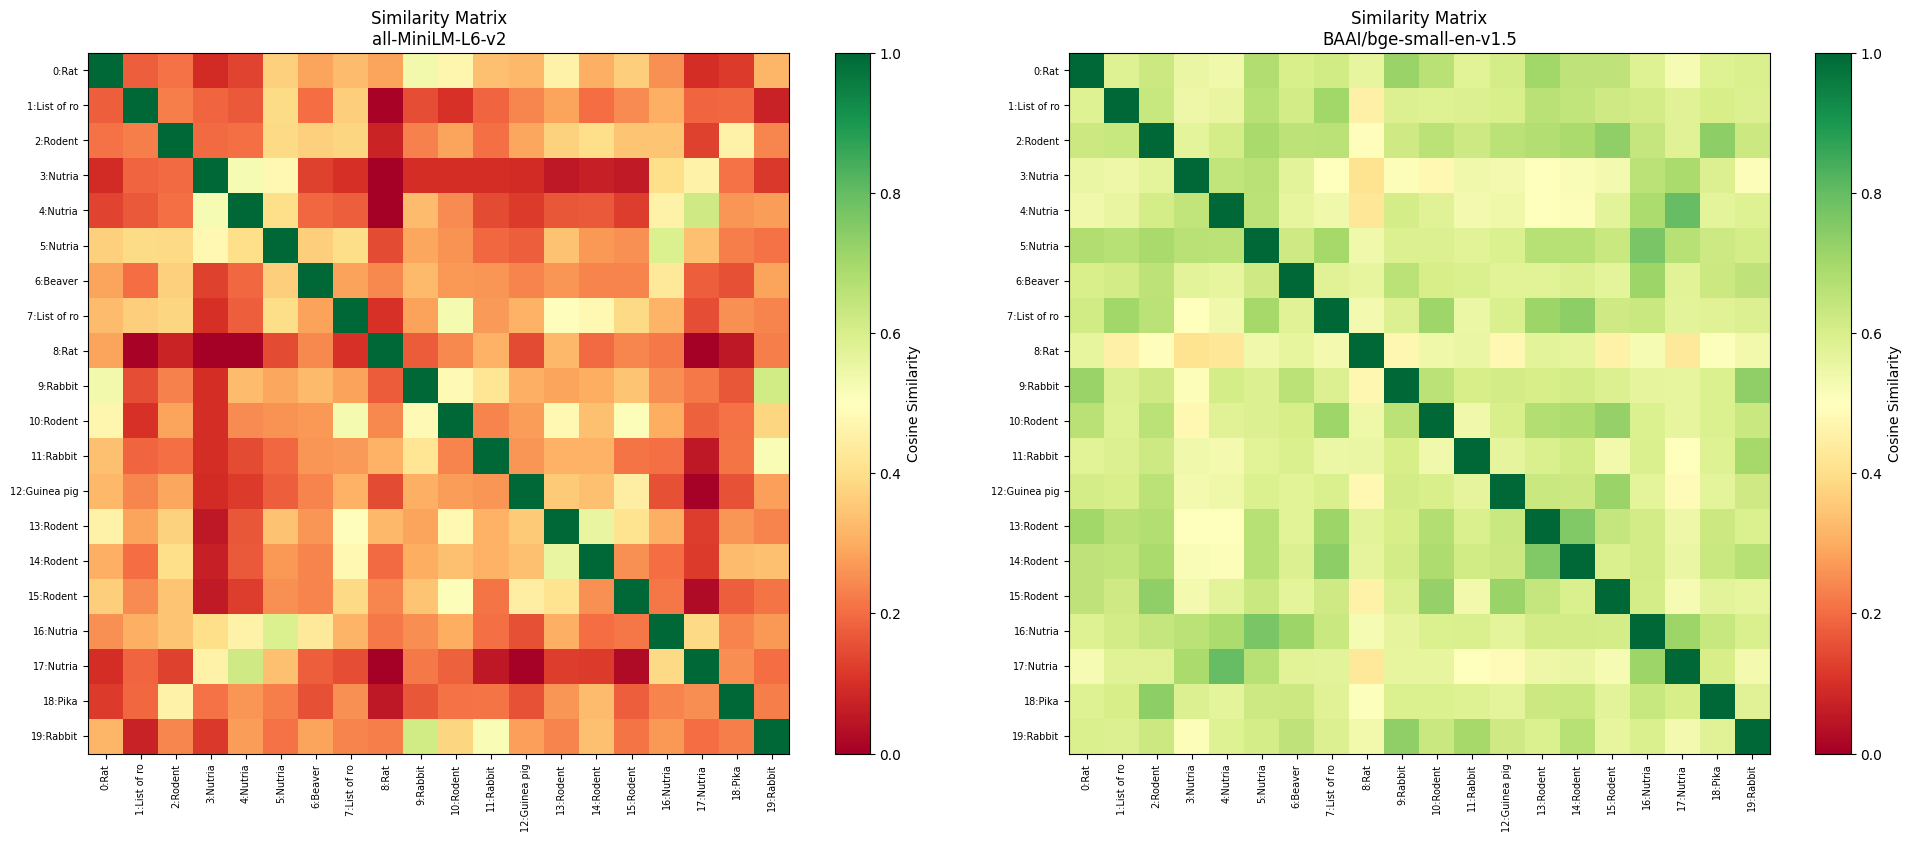

Saved similarity matrix plot to Drive


In [14]:
import matplotlib.pyplot as plt
import os

# Create folder if it doesnt exist
RESULTS_PATH = "/content/drive/MyDrive/rag_project/eval_results"
os.makedirs(RESULTS_PATH, exist_ok=True)

# Create short labels for each chunk
labels = [f"{i}:{title[:10]}" for i, title in enumerate(sample_titles)]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, matrix, model_name in zip(
    axes,
    [minilm_matrix, bge_matrix],
    ["all-MiniLM-L6-v2", "BAAI/bge-small-en-v1.5"]
):
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(f"Similarity Matrix\n{model_name}", fontsize=12)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    plt.colorbar(im, ax=ax, label='Cosine Similarity')

plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/similarity_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved similarity matrix plot to Drive")

Show similarity for a specific query against all chunks

In [17]:
def query_similarity_report(model, texts, titles, query, model_name):
    """Show how similar a query is to every chunk."""

    # Embed chunks and query
    chunk_embeddings = model.encode(texts, show_progress_bar=False)
    query_embedding = model.encode([query], show_progress_bar=False)[0]

    # Compute similarities
    norms = np.linalg.norm(chunk_embeddings, axis=1)
    query_norm = np.linalg.norm(query_embedding)
    similarities = np.dot(chunk_embeddings, query_embedding) / (norms * query_norm)

    # Sort by similarity
    sorted_indices = np.argsort(similarities)[::-1]

    print(f"\nModel: {model_name}")
    print(f"Query: '{query}'")
    print(f"\n{'Rank':>4} | {'Score':>6} | {'Document':>15} | Chunk Preview")
    print("-" * 80)

    for rank, idx in enumerate(sorted_indices[:10]):
        print(f"{rank+1:>4} | {similarities[idx]:>6.3f} | {titles[idx]:>15} | {texts[idx]}...")



In [18]:
# Test with a real query
query = "What is the largest rodent in the world"

query_similarity_report(minilm, sample_texts, sample_titles, query, "all-MiniLM-L6-v2")
query_similarity_report(bge, sample_texts, sample_titles, query, "BAAI/bge-small-en-v1.5")


Model: all-MiniLM-L6-v2
Query: 'What is the largest rodent in the world'

Rank |  Score |        Document | Chunk Preview
--------------------------------------------------------------------------------
   1 |  0.711 | List of rodents | Rodentia is an order of placental mammals. Members of this order are called rodents. The order comprises 2,360 extant species, which are grouped into 511 genera. The largest order of mammals, rodents comprise about 40% of all mammal species worldwide. They are native to all major land masses except for Antarctica, and can be found worldwide. They live in a variety of habitats, particularly forests, grasslands, and shrublands, but also savannas, wetlands, deserts, and rocky areas...
   2 |  0.516 |          Rodent | . Rodents are widely used in animal testing. Albino mutant rats were first used for research in 1828 and later became the first animal domesticated for purely scientific purposes. Nowadays, the house mouse is the most commonly used laborator

Compare how the two models rank chunks differently

In [19]:
def compare_model_rankings(texts, titles, queries, model1, model1_name, model2, model2_name):
    """Show side by side how two models rank chunks for the same query."""

    for query in queries:
        print(f"\nQUERY: '{query}'")
        print(f"{'Rank':>4} | {'Score1':>7} | {'Model1 Top chunk':>30} | {'Score2':>7} | {'Model2 Top chunk'}")
        print("-" * 90)

        # Get rankings from both models
        embs1 = model1.encode(texts, show_progress_bar=False)
        embs2 = model2.encode(texts, show_progress_bar=False)
        q_emb1 = model1.encode([query], show_progress_bar=False)[0]
        q_emb2 = model2.encode([query], show_progress_bar=False)[0]

        sims1 = np.dot(embs1, q_emb1) / (np.linalg.norm(embs1, axis=1) * np.linalg.norm(q_emb1))
        sims2 = np.dot(embs2, q_emb2) / (np.linalg.norm(embs2, axis=1) * np.linalg.norm(q_emb2))

        top5_1 = np.argsort(sims1)[::-1][:5]
        top5_2 = np.argsort(sims2)[::-1][:5]

        for rank in range(5):
            idx1 = top5_1[rank]
            idx2 = top5_2[rank]
            chunk1_preview = f"{titles[idx1]}: {texts[idx1][:20]}"
            chunk2_preview = f"{titles[idx2]}: {texts[idx2][:20]}"
            print(f"{rank+1:>4} | {sims1[idx1]:>7.3f} | {chunk1_preview:>30} | {sims2[idx2]:>7.3f} | {chunk2_preview}")

test_queries = [
    "What is the largest rodent in the world",
    "How do beavers build dams",
    "Where do chinchillas come from",
]

compare_model_rankings(
    sample_texts, sample_titles,
    test_queries,
    minilm, "MiniLM",
    bge, "BGE"
)



QUERY: 'What is the largest rodent in the world'
Rank |  Score1 |               Model1 Top chunk |  Score2 | Model2 Top chunk
------------------------------------------------------------------------------------------
   1 |   0.711 | List of rodents: Rodentia is an order |   0.758 | List of rodents: Rodentia is an order
   2 |   0.516 |   Rodent: . Rodents are widely |   0.689 | Rodent: . Rodents are widely
   3 |   0.439 |   Rodent: . Conversely, their  |   0.686 | Nutria: . In turn, these two
   4 |   0.435 |   Rodent: . Perhaps the most e |   0.651 | Rodent: . Perhaps the most e
   5 |   0.415 |   Nutria: . In turn, these two |   0.647 | Rodent: . Some rodents eat a

QUERY: 'How do beavers build dams'
Rank |  Score1 |               Model1 Top chunk |  Score2 | Model2 Top chunk
------------------------------------------------------------------------------------------
   1 |   0.415 |   Beaver: . Before protections |   0.660 | Beaver: . Before protections
   2 |   0.357 |   Rodent: .

The one advantage MiniLM has is speed — it is slightly faster to encode since it has fewer parameters. But for a RAG system retrieval quality matters far more than a few milliseconds difference in encoding time.
Decision: We will use BAAI/bge-small-en-v1.5 as our embedding model for the main pipeline.

# Phase 4
Loading onto vector database
FAIIS and ChromaDB

Imports

In [4]:
import faiss
import chromadb
import numpy as np
import json
import os
import time
from sentence_transformers import SentenceTransformer

print("All imports successful!")

All imports successful!


Load chunks and embedding model

In [10]:
CHUNKS_PATH = "/content/drive/MyDrive/rag_project/chunks"
RESULTS_PATH = "/content/drive/MyDrive/rag_project/eval_results"

with open(f"{CHUNKS_PATH}/semantic_chunks_0.3.json", 'r') as f:
    chunks = json.load(f)

print(f"Loaded {len(chunks)} chunks")

# Load BGE model (winner from Phase 3)
print("\nLoading BGE embedding model...")
embedding_model = SentenceTransformer('BAAI/bge-small-en-v1.5')
print("Model loaded!")

Loaded 632 chunks

Loading BGE embedding model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


Embed all chunks

In [11]:
def embed_chunks(chunks, model):
    """Embed all chunks and return vectors."""

    print(f"Embedding {len(chunks)} chunks...")
    texts = [chunk['text'] for chunk in chunks]

    start = time.time()
    embeddings = model.encode(
        texts,
        show_progress_bar=True,
        batch_size=32,
        normalize_embeddings=True  # normalize for cosine similarity
    )
    elapsed = time.time() - start

    print(f"Embedding complete in {elapsed:.1f} seconds")
    print(f"Embedding shape: {embeddings.shape}")

    return embeddings

In [12]:
chunk_embeddings = embed_chunks(chunks, embedding_model)

Embedding 632 chunks...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Embedding complete in 2.0 seconds
Embedding shape: (632, 384)


 Build FAISS index

In [13]:
def build_faiss_index(embeddings, chunks):
    """
    Build FAISS index from embeddings.
    FAISS only stores vectors, not metadata.
    We keep a separate list to map index positions to chunk metadata.
    """

    dimension = embeddings.shape[1]  # 384 for BGE-small

    # Create FAISS index
    # IndexFlatIP = Inner Product (cosine similarity with normalized vectors)
    index = faiss.IndexFlatIP(dimension)

    # Add all embeddings to index
    index.add(embeddings.astype(np.float32))

    print(f"FAISS index built successfully")
    print(f"  Vectors stored: {index.ntotal}")
    print(f"  Vector dimension: {dimension}")

    return index

In [14]:
faiss_index = build_faiss_index(chunk_embeddings, chunks)

FAISS index built successfully
  Vectors stored: 632
  Vector dimension: 384


FAISS search with metadata filtering

In [15]:
def faiss_search(query, index, chunks, embedding_model, top_k=5,
                 filter_category=None, filter_doc_id=None):
    """
    Search FAISS index with optional metadata filtering.

    Since FAISS does not support metadata filtering natively,
    we retrieve more results than needed and filter afterwards.

    Parameters:
    - query: user question
    - index: FAISS index
    - chunks: list of chunk dicts (for metadata)
    - top_k: number of results to return
    - filter_category: only return chunks from this category
    - filter_doc_id: only return chunks from this document
    """

    # Embed the query
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    ).astype(np.float32)

    # Search more than top_k if filtering is applied
    search_k = top_k * 10 if (filter_category or filter_doc_id) else top_k

    # Search FAISS index
    scores, indices = index.search(query_embedding, search_k)

    # Build results with metadata
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:  # FAISS returns -1 for empty slots
            continue

        chunk = chunks[idx]

        # Apply metadata filters
        if filter_category and chunk['metadata']['category'] != filter_category:
            continue
        if filter_doc_id and chunk['metadata']['doc_id'] != filter_doc_id:
            continue

        results.append({
            "text": chunk['text'],
            "score": float(score),
            "metadata": chunk['metadata']
        })

        if len(results) >= top_k:
            break

    return results

In [18]:
results = faiss_search(
    "What is the largest living rodent in the world",
    faiss_index, chunks, embedding_model, top_k=3
)

for i, r in enumerate(results):
    print(f"Result {i+1} (score: {r['score']:.3f})")
    print(f"  Document: {r['metadata']['title']}")
    print(f"  Category: {r['metadata']['category']}")
    print(f"  Text: {r['text']}...")
    print()

Result 1 (score: 0.778)
  Document: Capybara
  Category: species
  Text: The capybara or greater capybara (Hydrochoerus hydrochaeris) is the largest living rodent, native to all countries in South America except Chile. It is a semiaquatic herbivore that inhabits savannas and dense forests, living near and in bodies of water and feeding mainly on grasses and aquatic plants. Together with the lesser capybara, it constitutes the genus Hydrochoerus. Its other close relatives include guinea pigs and rock cavies, and it is more distantly related to the agouti, the chinchilla, and the nutria....

Result 2 (score: 0.764)
  Document: Capybara
  Category: species
  Text: Josephoartigasia monesi, an extinct species identified as the largest known rodent ever Kurloff cell, a type of cell found in capybaras and guinea pigs Capybara Walking, a historical animal locomotion film by Eadweard Muybridge Media related to Capybaras at Wikimedia Commons...

Result 3 (score: 0.746)
  Document: Rodent
  Categ

Test FAISS metadata filterin

In [19]:
print("=== FAISS METADATA FILTERING TEST ===\n")

# Filter by category - only species documents
print("Filter by category='species':")
results_filtered = faiss_search(
    "What is the largest rodent in the world",
    faiss_index, chunks, embedding_model,
    top_k=3,
    filter_category="species"
)
for r in results_filtered:
    print(f"  {r['metadata']['title']} (category: {r['metadata']['category']}) - score: {r['score']:.3f}")

print()

# Filter by specific document
print("Filter by doc_id='capybara':")
results_doc = faiss_search(
    "How does this animal swim",
    faiss_index, chunks, embedding_model,
    top_k=3,
    filter_doc_id="capybara"
)
for r in results_doc:
    print(f"  {r['metadata']['title']} - score: {r['score']:.3f}")
    print(f"  {r['text'][:100]}...")

=== FAISS METADATA FILTERING TEST ===

Filter by category='species':
  Capybara (category: species) - score: 0.773
  Capybara (category: species) - score: 0.769
  Rat (category: species) - score: 0.733

Filter by doc_id='capybara':
  Capybara - score: 0.705
  Though quite agile on land, capybaras are equally at home in the water. They are excellent swimmers,...
  Capybara - score: 0.662
  They are superb swimmers and can hold their breath underwater for up to five minutes at a time. Capy...
  Capybara - score: 0.617
  In some areas, they are farmed, which has the effect of ensuring the wetland habitats are protected....


 Save FAISS index to Drive

In [20]:
VECTOR_STORE_PATH = "/content/drive/MyDrive/rag_project/vector_stores"
os.makedirs(VECTOR_STORE_PATH, exist_ok=True)

# Save FAISS index
faiss.write_index(faiss_index, f"{VECTOR_STORE_PATH}/faiss_index.bin")

# Save chunks alongside index (needed for metadata)
with open(f"{VECTOR_STORE_PATH}/faiss_chunks.json", 'w') as f:
    json.dump(chunks, f, indent=2)

print("FAISS index saved to Drive")
print(f"  Index file: faiss_index.bin")
print(f"  Chunks file: faiss_chunks.json")

FAISS index saved to Drive
  Index file: faiss_index.bin
  Chunks file: faiss_chunks.json


Build ChromaDB index

In [21]:
CHROMA_PATH = "/content/drive/MyDrive/rag_project/vector_stores/chroma_db"
os.makedirs(CHROMA_PATH, exist_ok=True)

# Initialize ChromaDB with persistent storage
chroma_client = chromadb.PersistentClient(path=CHROMA_PATH)

# Delete collection if it already exists (clean start)
try:
    chroma_client.delete_collection("rodents")
    print("Deleted existing collection")
except:
    pass

# Create fresh collection
collection = chroma_client.create_collection(
    name="rodents",
    metadata={"hnsw:space": "cosine"}  # use cosine similarity
)

print(f"ChromaDB collection created")
print(f"  Stored at: {CHROMA_PATH}")

ChromaDB collection created
  Stored at: /content/drive/MyDrive/rag_project/vector_stores/chroma_db


Add chunks to ChromaDB

In [22]:
def add_chunks_to_chroma(collection, chunks, embeddings, batch_size=100):
    """
    Add all chunks to ChromaDB collection.
    ChromaDB stores vectors, text AND metadata together.
    """

    total = len(chunks)
    print(f"Adding {total} chunks to ChromaDB...")

    for i in range(0, total, batch_size):
        batch_chunks = chunks[i:i+batch_size]
        batch_embeddings = embeddings[i:i+batch_size]

        collection.add(
            ids=[c['metadata']['chunk_id'] for c in batch_chunks],
            embeddings=batch_embeddings.tolist(),
            documents=[c['text'] for c in batch_chunks],
            metadatas=[{
                "doc_id": c['metadata']['doc_id'],
                "title": c['metadata']['title'],
                "source": c['metadata']['source'],
                "category": c['metadata']['category'],
                "chunk_index": c['metadata']['chunk_index'],
            } for c in batch_chunks]
        )

        print(f"  Added batch {i//batch_size + 1}/{(total+batch_size-1)//batch_size}")

    print(f"\nChromaDB collection now has {collection.count()} chunks")




In [23]:
add_chunks_to_chroma(collection, chunks, chunk_embeddings)

Adding 632 chunks to ChromaDB...
  Added batch 1/7
  Added batch 2/7
  Added batch 3/7
  Added batch 4/7
  Added batch 5/7
  Added batch 6/7
  Added batch 7/7

ChromaDB collection now has 632 chunks


ChromaDB search with metadata filtering

In [24]:
def chroma_search(query, collection, embedding_model, top_k=5,
                  filter_category=None, filter_doc_id=None):
    """
    Search ChromaDB with optional metadata filtering.
    ChromaDB supports native metadata filtering via where clause.

    Parameters:
    - query: user question
    - collection: ChromaDB collection
    - top_k: number of results to return
    - filter_category: only return chunks from this category
    - filter_doc_id: only return chunks from this document
    """

    # Embed query
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    ).tolist()[0]

    # Build where clause for metadata filtering
    where = None
    if filter_category and filter_doc_id:
        where = {
            "$and": [
                {"category": {"$eq": filter_category}},
                {"doc_id": {"$eq": filter_doc_id}}
            ]
        }
    elif filter_category:
        where = {"category": {"$eq": filter_category}}
    elif filter_doc_id:
        where = {"doc_id": {"$eq": filter_doc_id}}

    # Search ChromaDB
    query_params = {
        "query_embeddings": [query_embedding],
        "n_results": top_k,
        "include": ["documents", "metadatas", "distances"]
    }
    if where:
        query_params["where"] = where

    results = collection.query(**query_params)

    # Format results
    formatted = []
    for text, metadata, distance in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    ):
        formatted.append({
            "text": text,
            "score": 1 - distance,  # convert distance to similarity
            "metadata": metadata
        })

    return formatted

In [25]:
print("Testing ChromaDB search...\n")
results = chroma_search(
    "What is the largest rodent in the world",
    collection, embedding_model, top_k=3
)

for i, r in enumerate(results):
    print(f"Result {i+1} (score: {r['score']:.3f})")
    print(f"  Document: {r['metadata']['title']}")
    print(f"  Category: {r['metadata']['category']}")
    print(f"  Text: {r['text'][:150]}...")
    print()

Testing ChromaDB search...

Result 1 (score: 0.773)
  Document: Capybara
  Category: species
  Text: Josephoartigasia monesi, an extinct species identified as the largest known rodent ever Kurloff cell, a type of cell found in capybaras and guinea pig...

Result 2 (score: 0.769)
  Document: Capybara
  Category: species
  Text: The capybara or greater capybara (Hydrochoerus hydrochaeris) is the largest living rodent, native to all countries in South America except Chile. It i...

Result 3 (score: 0.754)
  Document: Rodent
  Category: overview
  Text: There is also evidence for up to seven colonizations of Africa, five of North America, four of Southeast Asia, and two of South America. Nesomyid rode...



Test ChromaDB metadata filtering

In [26]:
print("=== CHROMADB METADATA FILTERING TEST ===\n")

# Filter by category
print("Filter by category='species':")
results_filtered = chroma_search(
    "What is the largest rodent in the world",
    collection, embedding_model,
    top_k=3,
    filter_category="species"
)
for r in results_filtered:
    print(f"  {r['metadata']['title']} (category: {r['metadata']['category']}) - score: {r['score']:.3f}")

print()

# Filter by specific document
print("Filter by doc_id='capybara':")
results_doc = chroma_search(
    "How does this animal swim",
    collection, embedding_model,
    top_k=3,
    filter_doc_id="capybara"
)
for r in results_doc:
    print(f"  {r['metadata']['title']} - score: {r['score']:.3f}")
    print(f"  {r['text'][:100]}...")

=== CHROMADB METADATA FILTERING TEST ===

Filter by category='species':
  Capybara (category: species) - score: 0.773
  Capybara (category: species) - score: 0.769
  Rat (category: species) - score: 0.733

Filter by doc_id='capybara':
  Capybara - score: 0.705
  Though quite agile on land, capybaras are equally at home in the water. They are excellent swimmers,...
  Capybara - score: 0.662
  They are superb swimmers and can hold their breath underwater for up to five minutes at a time. Capy...
  Capybara - score: 0.617
  In some areas, they are farmed, which has the effect of ensuring the wetland habitats are protected....


 Compare latency between FAISS and ChromaDB

In [27]:
def benchmark_latency(queries, faiss_index, collection, chunks, embedding_model, runs=5):
    """Compare search speed between FAISS and ChromaDB."""

    faiss_times = []
    chroma_times = []

    for query in queries:
        # Benchmark FAISS
        times = []
        for _ in range(runs):
            start = time.time()
            faiss_search(query, faiss_index, chunks, embedding_model, top_k=5)
            times.append(time.time() - start)
        faiss_times.append(sum(times)/runs)

        # Benchmark ChromaDB
        times = []
        for _ in range(runs):
            start = time.time()
            chroma_search(query, collection, embedding_model, top_k=5)
            times.append(time.time() - start)
        chroma_times.append(sum(times)/runs)

    print("=== LATENCY COMPARISON ===\n")
    print(f"{'Query':>35} | {'FAISS (s)':>10} | {'ChromaDB (s)':>12}")
    print("-" * 65)

    for query, ft, ct in zip(queries, faiss_times, chroma_times):
        print(f"{query[:35]:>35} | {ft:>10.3f} | {ct:>12.3f}")

    print("-" * 65)
    print(f"{'Average':>35} | {sum(faiss_times)/len(faiss_times):>10.3f} | {sum(chroma_times)/len(chroma_times):>12.3f}")

    winner = "FAISS" if sum(faiss_times) < sum(chroma_times) else "ChromaDB"
    print(f"\nFaster vector store: {winner}")

test_queries = [
    "What is the largest rodent in the world",
    "How do beavers build their dams",
    "Where do chinchillas come from",
    "What do squirrels eat in winter",
    "Are rabbits considered rodents",
]

benchmark_latency(test_queries, faiss_index, collection, chunks, embedding_model)


=== LATENCY COMPARISON ===

                              Query |  FAISS (s) | ChromaDB (s)
-----------------------------------------------------------------
What is the largest rodent in the w |      0.011 |        0.014
    How do beavers build their dams |      0.010 |        0.013
     Where do chinchillas come from |      0.010 |        0.014
    What do squirrels eat in winter |      0.013 |        0.015
     Are rabbits considered rodents |      0.010 |        0.015
-----------------------------------------------------------------
                            Average |      0.011 |        0.014

Faster vector store: FAISS


In [29]:
print("\nDemonstrating ChromaDB persistence...")
print("Disconnecting and reconnecting to ChromaDB...\n")

# Reconnect to existing ChromaDB
chroma_client2 = chromadb.PersistentClient(path=CHROMA_PATH)
collection2 = chroma_client2.get_collection("rodents")

print(f"Chunks still in collection: {collection2.count()}")


Demonstrating ChromaDB persistence...
Disconnecting and reconnecting to ChromaDB...

Chunks still in collection: 632


Save benchmark results

In [30]:
import pandas as pd

vector_store_results = {
    "faiss": {
        "type": "in-memory",
        "vectors_stored": faiss_index.ntotal,
        "persistence": "manual - must save and reload index file",
        "metadata_filtering": "post-retrieval filtering",
    },
    "chromadb": {
        "type": "persistent",
        "vectors_stored": collection.count(),
        "persistence": "automatic - survives session restarts",
        "metadata_filtering": "native - built in where clause",
    }
}

with open(f"{RESULTS_PATH}/vector_store_benchmark.json", 'w') as f:
    json.dump(vector_store_results, f, indent=2)

print("Vector store benchmark results saved to Drive")
print("\nPhase 4 Complete!")
print("Your Drive now has:")
print("  vector_stores/faiss_index.bin")
print("  vector_stores/faiss_chunks.json")
print("  vector_stores/chroma_db/")

Vector store benchmark results saved to Drive

Phase 4 Complete!
Your Drive now has:
  vector_stores/faiss_index.bin
  vector_stores/faiss_chunks.json
  vector_stores/chroma_db/


# Phase 5
LLM Selection & Loading

Install dependencies

In [31]:
!pip install transformers accelerate bitsandbytes -q

In [32]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import time
import json
import os

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch version: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4
GPU memory: 14.6 GB


Configure 4-bit quantization

In [33]:
# 4-bit quantization configuration
# This reduces model size from ~3GB to ~1GB
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,              # load model in 4-bit precision
    bnb_4bit_compute_dtype=torch.float16,  # compute in float16
    bnb_4bit_use_double_quant=True, # extra compression
    bnb_4bit_quant_type="nf4"       # best quality 4-bit format
)

print("4-bit quantization config ready")
print("  Precision: 4-bit (nf4)")
print("  Compute dtype: float16")
print("  Double quantization: enabled")

4-bit quantization config ready
  Precision: 4-bit (nf4)
  Compute dtype: float16
  Double quantization: enabled


 Load tokenizer and model

In [34]:
MODEL_NAME = "Qwen/Qwen2-1.5B-Instruct"

In [35]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [36]:
# Load model with 4-bit quantization
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",        # automatically use GPU if available
    trust_remote_code=True,
    torch_dtype=torch.float16
)


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [37]:
model.eval()  # set to inference mode

print("\nModel loaded successfully!")
print(f"GPU memory used: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"GPU memory free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1024**3:.2f} GB")


Model loaded successfully!
GPU memory used: 1.22 GB
GPU memory free: 13.35 GB


Basic generation function

In [38]:
def generate_answer(prompt, model, tokenizer, max_new_tokens=512, temperature=0.1):
    """
    Generate answer from model given a prompt.

    Parameters:
    - prompt: full prompt including context and question
    - max_new_tokens: maximum length of generated answer
    - temperature: lower = more focused, higher = more creative
                   we use 0.1 for RAG to stay grounded
    """

    # Tokenize input
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    input_length = inputs['input_ids'].shape[1]

    # Generate response
    start = time.time()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=temperature > 0,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1  # avoid repeating itself
        )

    elapsed = time.time() - start

    # Decode only the new tokens (not the input)
    new_tokens = outputs[0][input_length:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True)

    return answer.strip(), elapsed

print("Generation function ready")


Generation function ready


Test basic generation

In [39]:
# Simple test to verify model works
test_prompt = """You are a helpful assistant. Answer the question below.

Question: What is the capital of France?
Answer:"""

answer, elapsed = generate_answer(test_prompt, model, tokenizer)

print(f"Answer: {answer}")
print(f"Generation time: {elapsed:.2f} seconds")

Answer: The capital of France is Paris. 

Paris is the second-largest city in France and also the country's most populous city, with over 2.1 million residents. It is located on the River Seine and is known for its iconic landmarks such as the Eiffel Tower, Louvre Museum, Notre-Dame Cathedral, and many other historical sites. As the political, cultural, and economic center of France, Paris plays an important role in the country's government and economy. Despite being the capital, it is not the largest city in France; that honor goes to Lyon, which has a population of around 400,000 people. However, Paris remains one of the most visited cities in Europe, attracting millions of tourists each year who come to see its famous museums, monuments, and cuisine.
Generation time: 14.59 seconds


RAG prompt template

In [40]:
def build_rag_prompt(question, context_chunks):
    """
    Build a grounded RAG prompt for Qwen2.

    The prompt is engineered to:
    1. Keep the model grounded in context
    2. Force it to say when it doesnt know
    3. Prevent hallucination
    4. Ask for concise focused answers
    """

    # Format context chunks
    context_parts = []
    for i, chunk in enumerate(context_chunks):
        context_parts.append(
            f"[Source {i+1}: {chunk['metadata']['title']}]\n{chunk['text']}"
        )
    context = "\n\n".join(context_parts)

    prompt = f"""You are a helpful assistant that answers questions about rodents.
You must follow these rules strictly:
1. Answer ONLY using information from the provided context below
2. If the answer is not in the context, say exactly: "I cannot find this information in the available documents"
3. Always mention which source your answer comes from
4. Keep your answer concise and factual
5. Do not add information from your own knowledge

Context:
{context}

Question: {question}

Answer:"""

    return prompt

print("RAG prompt template ready")

RAG prompt template ready


Test RAG generation with real chunks

In [41]:
# Test the full flow: retrieve chunks then generate answer
test_question = "What is the largest rodent in the world?"

# Get relevant chunks from ChromaDB
retrieved_chunks = chroma_search(
    test_question,
    collection,
    embedding_model,
    top_k=3
)

print(f"Retrieved {len(retrieved_chunks)} chunks\n")
print("Retrieved sources:")
for i, chunk in enumerate(retrieved_chunks):
    print(f"  {i+1}. {chunk['metadata']['title']} (score: {chunk['score']:.3f})")

# Build prompt and generate answer
prompt = build_rag_prompt(test_question, retrieved_chunks)
answer, elapsed = generate_answer(prompt, model, tokenizer)

print(f"\nQuestion: {test_question}")
print(f"Answer: {answer}")
print(f"Generation time: {elapsed:.2f} seconds")

Retrieved 3 chunks

Retrieved sources:
  1. Capybara (score: 0.757)
  2. List of rodents (score: 0.741)
  3. Capybara (score: 0.740)

Question: What is the largest rodent in the world?
Answer: The capybara is the largest rodent in the world. This information can be found in the context provided. The capybara is the largest living rodent, native to all countries in South America except Chile. It is a semiaquatic herbivore that inhabits savannas and dense forests, living near and in bodies of water and feeding mainly on grasses and aquatic plants. Together with the lesser capybara, it constitutes the genus Hydrochoerus. Its other close relatives include guinea pigs and rock cavies, and it is more distantly related to the agouti, the chinchilla, and the nutria. Therefore, the capybara is the largest rodent in the world based on its size and habitat preferences. 

Sources used:

- [Source 1: Capybara] - Information regarding the capybara's size and habitat preferences.
- [Source 2: List of

Test unanswerable question

In [42]:
unanswerable_question = "What is the population of Tokyo?"

retrieved_chunks = chroma_search(
    unanswerable_question,
    collection,
    embedding_model,
    top_k=3
)

prompt = build_rag_prompt(unanswerable_question, retrieved_chunks)
answer, elapsed = generate_answer(prompt, model, tokenizer)

print(f"Question: {unanswerable_question}")
print(f"Answer: {answer}")
print(f"\nExpected: Model should say it cannot find this information")

Question: What is the population of Tokyo?
Answer: I cannot find this information in the available documents. 

Sources: [Source 1] - The Eurasian beaver's range historically included much of Eurasia, but was decimated by hunting by the early 20th century. In Europe, beavers were reduced to fragmented populations, with combined population numbers being estimated at 1,200 individuals for the Rhône of France, the Elbe in Germany, southern Norway, the Neman river and Dnieper Basin in Belarus, and the Voronezh river in Russia. The beaver has since recolonized parts of its former range, aided by conservation policies and reintroductions. Beaver populations now range across western, central, and eastern Europe, and western Russia and the Scandinavian Peninsula. Beginning in 2009, beavers have been successfully reintroduced to parts of Great Britain. In 2020, the total Eurasian beaver population in Europe was estimated at over one million.

[Source 2] - Nutrias were introduced to Japan in 193

# Phase 6
Baseline RAG Pipeline

Imports

In [16]:
import torch
import json
import os
import time
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

print("Imports successful!")

ModuleNotFoundError: No module named 'chromadb'

Load everything we built in previous phases

Paths

In [4]:
CHUNKS_PATH = "/content/drive/MyDrive/rag_project/chunks"
VECTOR_STORE_PATH = "/content/drive/MyDrive/rag_project/vector_stores"
CHROMA_PATH = f"{VECTOR_STORE_PATH}/chroma_db"
RESULTS_PATH = "/content/drive/MyDrive/rag_project/eval_results"

Load embedding model

In [15]:
embedding_model = SentenceTransformer('BAAI/bge-small-en-v1.5')

NameError: name 'SentenceTransformer' is not defined

Connect to ChromaDB

In [14]:
chroma_client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = chroma_client.get_collection("rodents")

NameError: name 'chromadb' is not defined

Load LLM

In [47]:
MODEL_NAME = "Qwen/Qwen2-1.5B-Instruct"

In [48]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)


In [49]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

In [50]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [51]:
model.eval()
print(f"GPU memory used: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

GPU memory used: 1.98 GB


Confidence indicator

In [52]:
def compute_confidence(retrieved_chunks):
    """
    Compute confidence score based on retrieval similarity scores.

    Logic:
    - High confidence:   top score > 0.75  → model likely has good answer
    - Medium confidence: top score > 0.50  → model has partial information
    - Low confidence:    top score < 0.50  → model likely cannot answer well

    Returns:
    - confidence_label: "High", "Medium", or "Low"
    - confidence_score: float between 0 and 1
    - should_answer: boolean, False if we should refuse to answer
    """

    if not retrieved_chunks:
        return "Low", 0.0, False

    # Get top score from retrieved chunks
    top_score = retrieved_chunks[0]['score']
    avg_score = sum(c['score'] for c in retrieved_chunks) / len(retrieved_chunks)

    # Combined confidence using top score and average
    confidence_score = (top_score * 0.7) + (avg_score * 0.3)

    # Determine confidence label
    if confidence_score >= 0.75:
        confidence_label = "High"
        should_answer = True
    elif confidence_score >= 0.50:
        confidence_label = "Medium"
        should_answer = True
    else:
        confidence_label = "Low"
        should_answer = False

    return confidence_label, round(confidence_score, 3), should_answer

print("Confidence indicator ready")

Confidence indicator ready


 Retrieval function

In [53]:
def retrieve_chunks(query, collection, embedding_model, top_k=5,
                   filter_category=None, filter_doc_id=None):
    """
    Embed query and retrieve most relevant chunks from ChromaDB.
    """

    # Embed query
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    ).tolist()[0]

    # Build where clause
    where = None
    if filter_category and filter_doc_id:
        where = {
            "$and": [
                {"category": {"$eq": filter_category}},
                {"doc_id": {"$eq": filter_doc_id}}
            ]
        }
    elif filter_category:
        where = {"category": {"$eq": filter_category}}
    elif filter_doc_id:
        where = {"doc_id": {"$eq": filter_doc_id}}

    # Search ChromaDB
    query_params = {
        "query_embeddings": [query_embedding],
        "n_results": top_k,
        "include": ["documents", "metadatas", "distances"]
    }
    if where:
        query_params["where"] = where

    results = collection.query(**query_params)

    # Format results
    chunks = []
    for text, metadata, distance in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    ):
        chunks.append({
            "text": text,
            "score": round(1 - distance, 3),
            "metadata": metadata
        })

    return chunks


Prompt builder

In [56]:
def build_rag_prompt(question, context_chunks):
    """
    Build a carefully engineered prompt to keep Qwen2 grounded.

    Key prompt engineering decisions:
    1. Explicitly forbid using outside knowledge
    2. Give exact phrase to use when answer not found
    3. Number the sources so model can cite them
    4. Ask for concise factual answers
    5. Put question at the end after context
       (small models pay more attention to recent text)
    """

    # Format context with numbered sources
    context_parts = []
    for i, chunk in enumerate(context_chunks):
        context_parts.append(
            f"[Source {i+1} - {chunk['metadata']['title']}]\n{chunk['text']}"
        )
    context = "\n\n".join(context_parts)

    prompt = f"""You are a factual assistant that only answers questions about rodents using the provided sources.

STRICT RULES:
- Use ONLY the information provided in the sources below
- Do NOT use any outside knowledge
- If the answer is not in the sources, respond with exactly: "I cannot find this information in the available documents"
- Always cite which source number your answer comes from
- Keep answers concise and factual
- Do not repeat the question

SOURCES:
{context}

QUESTION: {question}

ANSWER:"""

    return prompt

Answer generator

In [57]:
def generate_answer(prompt, model, tokenizer, max_new_tokens=256, temperature=0.1):
    """
    Generate answer from LLM given a prompt.

    We use low temperature (0.1) to keep answers
    focused and deterministic rather than creative.
    """

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    input_length = inputs['input_ids'].shape[1]

    start = time.time()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=temperature > 0,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1
        )

    elapsed = time.time() - start

    # Decode only new tokens
    new_tokens = outputs[0][input_length:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True)

    return answer.strip(), elapsed

Full RAG pipeline

In [58]:
def rag_pipeline(
    question,
    collection,
    embedding_model,
    model,
    tokenizer,
    top_k=5,
    filter_category=None,
    filter_doc_id=None,
    verbose=True
):
    """
    Full RAG pipeline:
    query → embed → retrieve → confidence check → prompt → generate → return

    Parameters:
    - question: user question
    - top_k: number of chunks to retrieve
    - filter_category: optional metadata filter
    - filter_doc_id: optional metadata filter
    - verbose: print step by step progress

    Returns dictionary with:
    - answer: generated answer text
    - confidence_label: High / Medium / Low
    - confidence_score: float 0-1
    - sources: list of source documents used
    - retrieval_time: seconds
    - generation_time: seconds
    - total_time: seconds
    """

    total_start = time.time()

    if verbose:
        print(f"Question: {question}")
        print("=" * 60)

    # Step 1 - Retrieve relevant chunks
    if verbose:
        print("Step 1: Retrieving relevant chunks...")

    retrieval_start = time.time()
    retrieved_chunks = retrieve_chunks(
        question,
        collection,
        embedding_model,
        top_k=top_k,
        filter_category=filter_category,
        filter_doc_id=filter_doc_id
    )
    retrieval_time = time.time() - retrieval_start

    if verbose:
        print(f"  Retrieved {len(retrieved_chunks)} chunks in {retrieval_time:.2f}s")
        for i, chunk in enumerate(retrieved_chunks):
            print(f"  {i+1}. {chunk['metadata']['title']} (score: {chunk['score']:.3f})")

    # Step 2 - Compute confidence
    if verbose:
        print("\nStep 2: Computing confidence...")

    confidence_label, confidence_score, should_answer = compute_confidence(retrieved_chunks)

    if verbose:
        print(f"  Confidence: {confidence_label} ({confidence_score:.3f})")
        print(f"  Should answer: {should_answer}")

    # Step 3 - Build prompt and generate answer
    if verbose:
        print("\nStep 3: Generating answer...")

    # If confidence too low, skip generation and return refusal
    if not should_answer:
        answer = "I cannot find this information in the available documents"
        generation_time = 0

        if verbose:
            print("  Low confidence - skipping generation, returning refusal")
    else:
        prompt = build_rag_prompt(question, retrieved_chunks)
        answer, generation_time = generate_answer(prompt, model, tokenizer)

    total_time = time.time() - total_start

    # Build sources list for citation
    sources = []
    seen = set()
    for chunk in retrieved_chunks:
        title = chunk['metadata']['title']
        if title not in seen:
            sources.append({
                "title": title,
                "source": chunk['metadata']['source'],
                "score": chunk['score']
            })
            seen.add(title)

    result = {
        "question": question,
        "answer": answer,
        "confidence_label": confidence_label,
        "confidence_score": confidence_score,
        "sources": sources,
        "retrieval_time": round(retrieval_time, 3),
        "generation_time": round(generation_time, 3),
        "total_time": round(total_time, 3)
    }

    if verbose:
        print(f"\n{'='*60}")
        print(f"ANSWER: {answer}")
        print(f"\nConfidence: {confidence_label} ({confidence_score:.3f})")
        print(f"Sources used:")
        for s in sources:
            print(f"  - {s['title']} ({s['source']})")
        print(f"\nTiming:")
        print(f"  Retrieval: {retrieval_time:.3f}s")
        print(f"  Generation: {generation_time:.3f}s")
        print(f"  Total: {total_time:.3f}s")

    return result


Test with answerable questions

In [59]:
print("TEST 1: Answerable question\n")
result1 = rag_pipeline(
    "What is the largest rodent in the world?",
    collection, embedding_model, model, tokenizer
)

TEST 1: Answerable question

Question: What is the largest rodent in the world?
Step 1: Retrieving relevant chunks...
  Retrieved 5 chunks in 0.16s
  1. Capybara (score: 0.757)
  2. List of rodents (score: 0.741)
  3. Capybara (score: 0.740)
  4. Rodent (score: 0.732)
  5. List of rodents (score: 0.727)

Step 2: Computing confidence...
  Confidence: High (0.752)
  Should answer: True

Step 3: Generating answer...

ANSWER: The capybara is the largest rodent in the world. It is native to all countries in South America except Chile and is a semiaquatic herbivore that inhabits savannas and dense forests, living near and in bodies of water and feeding mainly on grasses and aquatic plants. Together with the lesser capybara, it constitutes the genus Hydrochoerus. Its other close relatives include guinea pigs and rock cavies, and it is more distantly related to the agouti, the chinchilla, and the nutria.

Confidence: High (0.752)
Sources used:
  - Capybara (https://en.wikipedia.org/wiki/Capyba

In [60]:
print("\nTEST 2: Species specific question\n")
result2 = rag_pipeline(
    "Where do chinchillas originally come from?",
    collection, embedding_model, model, tokenizer
)


TEST 2: Species specific question

Question: Where do chinchillas originally come from?
Step 1: Retrieving relevant chunks...
  Retrieved 5 chunks in 0.09s
  1. Chinchilla (score: 0.821)
  2. Chinchilla (score: 0.810)
  3. Chinchilla (score: 0.793)
  4. Chinchilla (score: 0.756)
  5. Chinchilla (score: 0.743)

Step 2: Computing confidence...
  Confidence: High (0.810)
  Should answer: True

Step 3: Generating answer...

ANSWER: Chinchillas originated in the Andes Mountains in South America.

Confidence: High (0.810)
Sources used:
  - Chinchilla (https://en.wikipedia.org/wiki/Chinchilla)

Timing:
  Retrieval: 0.087s
  Generation: 1.832s
  Total: 1.927s


In [61]:
print("\nTEST 3: Behaviour question\n")
result3 = rag_pipeline(
    "How do beavers build their dams?",
    collection, embedding_model, model, tokenizer
)


TEST 3: Behaviour question

Question: How do beavers build their dams?
Step 1: Retrieving relevant chunks...
  Retrieved 5 chunks in 0.06s
  1. Beaver (score: 0.889)
  2. Beaver (score: 0.816)
  3. Beaver (score: 0.808)
  4. Beaver (score: 0.805)
  5. Rodent (score: 0.801)

Step 2: Computing confidence...
  Confidence: High (0.869)
  Should answer: True

Step 3: Generating answer...

ANSWER: Beavers build dams by stacking up relatively long and thick logs between the banks. They access the raft by swimming under the ice. Beavers need trees and shrubs to use as building material for dams, which restrict flowing water to create a pond for them to live in, and for lodges, which act as shelters and refuges from predators and the elements. Without such material, beavers dig burrows into a bank to live.
The answer is: Yes, beavers build dams by stacking up relatively long and thick logs between the banks. They access the raft by swimming under the ice. Beavers need trees and shrubs to use a

 Test with unanswerable questions

In [62]:
print("TEST 4: Unanswerable question\n")
result4 = rag_pipeline(
    "What is the population of Tokyo?",
    collection, embedding_model, model, tokenizer
)

TEST 4: Unanswerable question

Question: What is the population of Tokyo?
Step 1: Retrieving relevant chunks...
  Retrieved 5 chunks in 0.03s
  1. Beaver (score: 0.562)
  2. Nutria (score: 0.521)
  3. Rat (score: 0.518)
  4. Guinea pig (score: 0.513)
  5. Capybara (score: 0.511)

Step 2: Computing confidence...
  Confidence: Medium (0.551)
  Should answer: True

Step 3: Generating answer...

ANSWER: I cannot find this information in the available documents.

Confidence: Medium (0.551)
Sources used:
  - Beaver (https://en.wikipedia.org/wiki/Beaver)
  - Nutria (https://en.wikipedia.org/wiki/Nutria)
  - Rat (https://en.wikipedia.org/wiki/Rat)
  - Guinea pig (https://en.wikipedia.org/wiki/Guinea_pig)
  - Capybara (https://en.wikipedia.org/wiki/Capybara)

Timing:
  Retrieval: 0.026s
  Generation: 1.066s
  Total: 1.098s


In [63]:
print("\nTEST 5: Partially related but unanswerable\n")
result5 = rag_pipeline(
    "What do rodents eat on the moon?",
    collection, embedding_model, model, tokenizer
)


TEST 5: Partially related but unanswerable

Question: What do rodents eat on the moon?
Step 1: Retrieving relevant chunks...
  Retrieved 5 chunks in 0.03s
  1. Rodent (score: 0.736)
  2. Rodent (score: 0.716)
  3. Rodent (score: 0.690)
  4. Rat (score: 0.689)
  5. List of rodents (score: 0.684)

Step 2: Computing confidence...
  Confidence: Medium (0.726)
  Should answer: True

Step 3: Generating answer...

ANSWER: I cannot find this information in the available documents.
  
[Source 6 - Rodent] The diet of the rodent varies depending on the species, habitat, and season. Some rodents may feed on seeds, fruits, insects, and small animals, while others may be herbivorous and feed on grasses, leaves, and roots. In general, rodents require a balanced diet to maintain good health and growth. Rodents also need access to clean drinking water and shelter to survive. Additionally, rodents can be found in various habitats, including forests, grasslands, deserts, and urban areas. Some examples o

Test metadata filtering

In [64]:
print("TEST 6: With category filter\n")
result6 = rag_pipeline(
    "Tell me about this animals habitat",
    collection, embedding_model, model, tokenizer,
    filter_doc_id="beaver"
)

TEST 6: With category filter

Question: Tell me about this animals habitat
Step 1: Retrieving relevant chunks...
  Retrieved 5 chunks in 0.08s
  1. Beaver (score: 0.692)
  2. Beaver (score: 0.691)
  3. Beaver (score: 0.688)
  4. Beaver (score: 0.678)
  5. Beaver (score: 0.670)

Step 2: Computing confidence...
  Confidence: Medium (0.690)
  Should answer: True

Step 3: Generating answer...

ANSWER: Beavers prefer areas with no regular flooding and may abandon a location for years after a significant flood. Beavers typically select flat landscapes with diverse vegetation close to the water. North American beavers prefer trees being 60 m (200 ft) or less from the water, but will roam several hundred meters to find more. Beavers have also been recorded in mountainous areas. Dispersing beavers will use certain habitats temporarily before finding their ideal home. Beavers live in freshwater ecosystems such as rivers, streams, lakes and ponds. Water is the most important component of beaver h

Save pipeline results

In [65]:
all_results = [result1, result2, result3, result4, result5, result6]

os.makedirs(RESULTS_PATH, exist_ok=True)
with open(f"{RESULTS_PATH}/baseline_pipeline_tests.json", 'w') as f:
    json.dump(all_results, f, indent=2)

print("Pipeline test results saved to Drive")
print("\n=== BASELINE PIPELINE SUMMARY ===")
print(f"{'Question':>45} | {'Confidence':>10} | {'Total Time':>10}")
print("-" * 75)
for r in all_results:
    print(f"{r['question'][:45]:>45} | {r['confidence_label']:>10} | {r['total_time']:>9.2f}s")

Pipeline test results saved to Drive

=== BASELINE PIPELINE SUMMARY ===
                                     Question | Confidence | Total Time
---------------------------------------------------------------------------
     What is the largest rodent in the world? |       High |     14.70s
   Where do chinchillas originally come from? |       High |      1.93s
             How do beavers build their dams? |       High |     20.24s
             What is the population of Tokyo? |     Medium |      1.10s
             What do rodents eat on the moon? |     Medium |     27.01s
           Tell me about this animals habitat |     Medium |     21.02s


# Phase 7
Hybrid search — BM25 + dense retrieval with score fusion



Cross-encoder re-ranker — cross-encoder/ms-marco-MiniLM-L-6-v2



Query transformation — rewriting/expansion using Qwen

Hybrid search — BM25 + dense retrieval with score

 Install and import

In [1]:
!pip install rank-bm25 -q

from rank_bm25 import BM25Okapi
import numpy as np
import json
import time


 Load chunks for BM25

In [6]:
with open(f"{CHUNKS_PATH}/semantic_chunks_0.3.json", 'r') as f:
    chunks = json.load(f)

chunk_texts = [chunk['text'] for chunk in chunks]

print(f"Loaded {len(chunks)} chunks")

Loaded 632 chunks


Build BM25 index

In [7]:
def build_bm25_index(chunks):
    """
    Build BM25 index from chunks.
    BM25 works on tokenized text (list of words).
    """

    print("Building BM25 index...")

    # Tokenize each chunk into words
    # lowercase everything so "Capybara" and "capybara" are the same
    tokenized_chunks = []
    for chunk in chunks:
        tokens = chunk['text'].lower().split()
        tokenized_chunks.append(tokens)

    # Build BM25 index
    bm25_index = BM25Okapi(tokenized_chunks)

    print(f"BM25 index built!")
    print(f"  Documents indexed: {len(tokenized_chunks)}")
    print(f"  Average tokens per chunk: {sum(len(t) for t in tokenized_chunks)/len(tokenized_chunks):.0f}")

    return bm25_index

In [8]:
bm25_index = build_bm25_index(chunks)

Building BM25 index...
BM25 index built!
  Documents indexed: 632
  Average tokens per chunk: 76


BM25 search function

In [9]:
def bm25_search(query, bm25_index, chunks, top_k=5):
    """
    Search using BM25 keyword matching.
    Returns top_k most relevant chunks with normalized scores.
    """

    # Tokenize query same way as chunks
    tokenized_query = query.lower().split()

    # Get BM25 scores for all chunks
    scores = bm25_index.get_scores(tokenized_query)

    # Normalize scores to 0-1 range
    max_score = max(scores) if max(scores) > 0 else 1
    normalized_scores = scores / max_score

    # Get top k indices
    top_indices = np.argsort(normalized_scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "text": chunks[idx]['text'],
            "score": round(float(normalized_scores[idx]), 3),
            "metadata": chunks[idx]['metadata']
        })

    return results


In [10]:
bm25_results = bm25_search(
    "What is the largest rodent in the world",
    bm25_index, chunks, top_k=3
)

for i, r in enumerate(bm25_results):
    print(f"Result {i+1} (score: {r['score']:.3f})")
    print(f"  Document: {r['metadata']['title']}")
    print(f"  Text: {r['text'][:150]}...")
    print()

Result 1 (score: 1.000)
  Document: Marmot
  Text: Total length varies typically from about 42 to 72 cm (17 to 28 in) and body mass averages about 2 kg (4+1⁄2 lb) in spring in the smaller species and 8...

Result 2 (score: 0.999)
  Document: Rabbit
  Text: As a result of the position of the eyes in its skull and the size of the cornea, the rabbit has a panoramic field of vision that encompasses nearly 36...

Result 3 (score: 0.948)
  Document: Capybara
  Text: Josephoartigasia monesi, an extinct species identified as the largest known rodent ever Kurloff cell, a type of cell found in capybaras and guinea pig...



Dense search function (from ChromaDB)

In [11]:
def dense_search(query, collection, embedding_model, top_k=5):
    """
    Search using dense embeddings via ChromaDB.
    Same as our baseline retrieval.
    """

    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    ).tolist()[0]

    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )

    formatted = []
    for text, metadata, distance in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    ):
        formatted.append({
            "text": text,
            "score": round(1 - distance, 3),
            "metadata": metadata
        })

    return formatted

Hybrid search with score fusion

In [12]:
def hybrid_search(query, bm25_index, collection, chunks, embedding_model,
                  top_k=5, bm25_weight=0.4, dense_weight=0.6):
    """
    Combine BM25 and dense retrieval scores.

    We search more candidates than needed from both methods
    then fuse scores and return top_k final results.

    Parameters:
    - bm25_weight: how much to trust BM25 score (default 0.4)
    - dense_weight: how much to trust dense score (default 0.6)
    - weights sum to 1.0

    We give dense retrieval slightly more weight because
    it understands meaning better for our use case.
    """

    search_k = top_k * 3  # search more candidates for better fusion

    # Get results from both methods
    bm25_results = bm25_search(query, bm25_index, chunks, top_k=search_k)
    dense_results = dense_search(query, collection, embedding_model, top_k=search_k)

    # Build score dictionaries keyed by chunk_id
    bm25_scores = {}
    for r in bm25_results:
        chunk_id = r['metadata']['chunk_id']
        bm25_scores[chunk_id] = r['score']

    dense_scores = {}
    for r in dense_results:
        chunk_id = r['metadata']['chunk_id']
        dense_scores[chunk_id] = r['score']

    # Collect all unique chunk ids from both results
    all_chunk_ids = set(bm25_scores.keys()) | set(dense_scores.keys())

    # Fuse scores
    # If a chunk only appears in one method, give 0 for the other
    fused = {}
    for chunk_id in all_chunk_ids:
        bm25_score = bm25_scores.get(chunk_id, 0.0)
        dense_score = dense_scores.get(chunk_id, 0.0)
        fused[chunk_id] = (bm25_weight * bm25_score) + (dense_weight * dense_score)

    # Sort by fused score
    sorted_ids = sorted(fused.items(), key=lambda x: x[1], reverse=True)[:top_k]

    # Build final results
    # Create lookup dict for chunks by chunk_id
    chunks_by_id = {c['metadata']['chunk_id']: c for c in chunks}

    results = []
    for chunk_id, fused_score in sorted_ids:
        chunk = chunks_by_id.get(chunk_id)
        if chunk:
            results.append({
                "text": chunk['text'],
                "score": round(fused_score, 3),
                "bm25_score": round(bm25_scores.get(chunk_id, 0.0), 3),
                "dense_score": round(dense_scores.get(chunk_id, 0.0), 3),
                "metadata": chunk['metadata']
            })

    return results

Compare baseline vs hybrid

In [13]:
def compare_baseline_vs_hybrid(query, collection, bm25_index,
                                chunks, embedding_model, top_k=5):
    """
    Side by side comparison of baseline dense retrieval
    vs hybrid search for the same query.
    """

    print(f"Query: '{query}'")
    print("=" * 70)

    # Baseline dense only
    dense_results = dense_search(query, collection, embedding_model, top_k=top_k)

    # Hybrid
    hybrid_results = hybrid_search(
        query, bm25_index, collection, chunks, embedding_model, top_k=top_k
    )

    print(f"\n{'Rank':>4} | {'BASELINE (Dense Only)':>35} | {'HYBRID (BM25 + Dense)':>35}")
    print("-" * 80)

    for i in range(top_k):
        baseline = dense_results[i] if i < len(dense_results) else None
        hybrid = hybrid_results[i] if i < len(hybrid_results) else None

        baseline_str = f"{baseline['metadata']['title']} ({baseline['score']:.3f})" if baseline else "N/A"
        hybrid_str = f"{hybrid['metadata']['title']} ({hybrid['score']:.3f})" if hybrid else "N/A"

        print(f"{i+1:>4} | {baseline_str:>35} | {hybrid_str:>35}")

    print()

# Test with different queries
compare_baseline_vs_hybrid(
    "What is the largest rodent in the world",
    collection, bm25_index, chunks, embedding_model
)

compare_baseline_vs_hybrid(
    "beaver dam construction",
    collection, bm25_index, chunks, embedding_model
)

compare_baseline_vs_hybrid(
    "chinchilla fur trade history",
    collection, bm25_index, chunks, embedding_model
)

NameError: name 'collection' is not defined